# Plotting the Z mass peak

<CENTER><img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/Resolution-Notebook/images/ATLASOD.gif?raw=1" style="width:50%"></CENTER>

This notebook uses ATLAS Open Data https://opendata.atlas.cern to teach you the concepts of how to study and reconstruct teh Z mass peak from studying muons.

ATLAS Open Data provides open access to proton-proton collision data at the LHC for educational purposes. ATLAS Open Data resources are ideal for high-school, undergraduate and postgraduate students.

## Drell-Yan Process
<CENTER><img src="DY_Feynman_Diagram.png" style="width:50%"></CENTER>



## Drell-Yan process
In this tutorial we will try to study the Drell-Yan process and plot the invariant mass of $Z/\gamma*.

We will plot the invariant mass for: $$Z/\gamma* \rightarrow \mu^{+}\mu^{-}$$ 
From the distribution try to estimate the Z mass.

*Think what might be $\gamma*$?

### A bit of theory (or recap)

Each of the muons,$\mu$ have a Energy-Momentum four vector associated with them along with charge. 
We are studying di-muons or two muons. Let their four vectors be given by:

$$v_1 = (E_1,p_{x1},p_{y1},p_{z1})$$
$$v_2 = (E_2,p_{x2},p_{y2},p_{z2})$$

Invariant mass is given by:
$$M_{inv} = \sqrt{(v_1 + v_2)^2} = \sqrt{(E_1+E_2)^2 - (p_{x1}+p_{x2})^2-(p_{y1}+p_{y2})^2-(p_{z1}+p_{z2})^2}$$

*Think how we get the energy of the muon?

### Running this Python notebook

A Python notebook consists of cell blocks, each containing lines of Python code. Each cell can be run independently of each other, yielding respective outputs below the cells. Conventionally, cells are run in order from top to bottom.

* To run the whole notebook, in the top menu click Cell $\rightarrow$ Run All.

* To propagate a change you've made to a piece of code, click Cell $\rightarrow$ Run All Below.

* You can also run a single code cell, by clicking Cell $\rightarrow$ Run Cells, or using the keyboard shortcut Shift+Enter.

For more information, refer to [this page](https://www.codecademy.com/article/how-to-use-jupyter-notebooks).

### First time package installation on your computer (not needed on mybinder)

This first cell installs the required python packages. It only needs to be run the first time you open this notebook on your computer. If you close Jupyter and re-open on the same computer, you won't need to run this first cell again. If this is opened on mybinder, you don't need to run this cell.

In [1]:
import sys
import os.path
from atlasopenmagic import install_from_environment
install_from_environment()

Installing packages: ['aiohttp>=3.9.5', 'atlasopenmagic>=1.2.0', 'awkward>=2.6.7', 'awkward-pandas>=2023.8.0', 'coffea~=0.7.0', 'fsspec>=2025.7.0', 'hist>=2.8.0', 'ipykernel>=6.29.5', 'jupyter>=1.0.0', 'lmfit>=1.3.2', 'matplotlib>=3.9.1', 'metakernel>=0.30.2', 'notebook<7', 'numpy>=1.26.4', 'pandas>=2.2.2', 'papermill>=2.6.0', 'pip>=24.2', 'scikit-learn>=1.5.1', 'uproot>=5.3.10', 'uproot3>=3.14.4', 'fsspec-xrootd>=0.5.1', 'jupyterlab_latex~=3.1.0', 'vector>=1.4.1']
  Using cached coffea-0.7.31-py2.py3-none-any.whl.metadata (9.6 kB)
  Using cached ipykernel-7.2.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
INFO: pip is looking at multiple versions of coffea to determine which version is compatible with other requirements. This could take a while.
  Using cached coffea-0.7.30-py2.py3-none-any.whl.metadata (9.6 kB)
  Using cached coffea-0.7.29-py2.py3-none-any.whl.metadata (9.6 kB)
  Using cach

## Importing Packages


We're going to import a number of packages to help us:

* `numpy`: provides numerical calculations such as histogramming

* `matplotlib`: common tool for making plots, figures, images, visualisations

* `uproot`: processes .root files typically used in particle physics into data formats used in python

* `awkward`: introduces awkward arrays, a format that generalizes numpy to nested data with possibly variable length lists

* `vector`: to allow vectorized 4-momentum calculations

In case these imports fail, try restarting the jupyter kernel and running again; it may simply be that the modules we installed in the previous cell have not yet been fully loaded.

In [2]:
import numpy as np # for numerical calculations such as histogramming
import matplotlib.pyplot as plt # for plotting
import matplotlib_inline # to edit the inline plot format
from matplotlib.ticker import AutoMinorLocator # for minor ticks
import sys
#sys.path.append("/root/.local/lib/python3.12/site-packages") #Added so that it picks up the correct root version
import uproot # for reading .root files
import awkward as ak # to represent nested data in columnar format
import vector # for 4-momentum calculations
import time # for printing time stamps
import requests # for file gathering, if needed; for HTTP access
from scipy.spatial import cKDTree # for making combinations in particle matching
from scipy.stats import norm # for gaussian distribution fit

## Accessing the Muon Datasets

In [3]:
# Get the files locally, rather than streaming the data (easier on the upstream servers)
local_files = True

Unit definitions, as stored in the data files:

In [4]:
MeV = 0.001
GeV = 1.0

To reinforce the ideas of detector and particle properties by looking at data from ATLAS experiments. We will use the [atlasopenmagic](https://opendata.atlas.cern/docs/data/atlasopenmagic) package to access the open data directly from the ATLAS OpenData Portal. The first step is import the module and load the release.

In [5]:
# ATLAS Open Data directory
import atlasopenmagic as atom
atom.available_releases()
atom.set_release('2025e-13tev-beta')

Fetching metadata for release: 2025e-13tev-beta...


Available releases:
2016e-8tev           2016 Open Data for education release of 8 TeV proton-proton collisions (https://opendata.cern.ch/record/3860).
2020e-13tev          2020 Open Data for education release of 13 TeV proton-proton collisions (https://cern.ch/2r7xt).
2024r-pp             2024 Open Data for research release for proton-proton collisions (https://opendata.cern.record/80020).
2024r-hi             2024 Open Data for research release for heavy-ion collisions (https://opendata.cern.ch/record/80035).
2025e-13tev-beta     2025 Open Data for education and outreach beta release for 13 TeV proton-proton collisions (https://opendata.cern.ch/record/93910).
2025r-evgen-13tev    2025 Open Data for research release for event generation at 13 TeV (https://opendata.cern.ch/record/160000).
2025r-evgen-13p6tev  2025 Open Data for research release for event generation at 13.6 TeV (https://opendata.cern.ch/record/160000).


Fetching datasets: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 374/374 [00:00<00:00, 534.80datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


For convenient naming and identification purposes, we define a dictionary which stores all the important names of the samples we want to pull from the database for this case study. The datset ID's can be found here on [this page](https://opendata.atlas.cern/docs/data/for_education/13TeV25_metadata).

In [6]:
mc_defs = {
    r'mu_mu': {'dids': [700323,700324,700325]},
    r'e_e': {'dids': [700320,700321,700322]},
    r'jets': {'dids': [364703,364706]},
}

# Step 1: Skimming 

For our first case study, we would like to explore the resolution of muon and electron reconstruction. We start by first choosing a `skim` for our analysis, which places cuts into our data. In this case, we will use the `2to4lep` skim and apply this into our dataset.

In [7]:
# Select the skim to use for the analysis
skim1 = "2to4lep"

mc_samples   = atom.build_mc_dataset(mc_defs, skim1, protocol='https')
data_samples = atom.build_data_dataset(skim1, protocol='https')

samples = {**data_samples, **mc_samples}
samples.keys()

/tmp/ipykernel_7896/1680887849.py:4: DeprecationWarning: The build_mc_dataset function is deprecated. Use build_dataset with the appropriate MC definitions instead.
  mc_samples   = atom.build_mc_dataset(mc_defs, skim1, protocol='https')
/tmp/ipykernel_7896/1680887849.py:5: DeprecationWarning: The build_data_dataset function is deprecated. Use build_dataset with the appropriate data definitions instead.
  data_samples = atom.build_data_dataset(skim1, protocol='https')


dict_keys(['Data', 'mu_mu', 'e_e', 'jets'])

Let's try accessing the first file in the `mu_mu` dataset as an example.

In [8]:
# We will use the first entry in 'list', from the 'mu_mu' dataset
value = samples['mu_mu']['list'][0]
print(f"{value = }")

# We can keep this file URL to peek into it and understanding what our data looks like
mu_mu_file = value

value = 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_mc_700323.Sh_2211_Zmumu_maxHTpTV2_BFilter.2to4lep.root'


The output `value` gives the URL link to the first sample in the `mu_mu` dataset (700323). This sample is stored in `mu_mu_file` and will be the one of the samples that we will use throughout this case study. We now want to open this file to see what's inside. The file contains a `tree`, which contains multiple entries, each representing an event. For each event, a dictionary stores all relevant information with keys, such as the event number (`eventNumber`), the photon transverse momentum (`photon_pt`), and more. (More information on trees can be viewed [here](https://notebooks.githubusercontent.com/view/%22https://masonproffitt.github.io/uproot-tutorial/03-trees/index.html%22).)

In [9]:
# Accessing the file from the online database (":analysis" opens the tree in a desired manner)
if local_files:

    # Download the file, use a local copy
    local_filename = mu_mu_file.split("/")[-1]
    print(f"Downloading {mu_mu_file} to {local_filename} ...")
    mu_mu_file_renamed = mu_mu_file.replace("simplecache::", "") 
    with requests.get(mu_mu_file_renamed, stream=True) as r:
        r.raise_for_status()
        with open(local_filename, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

    tree = uproot.open(local_filename + ":analysis")
else: # Stream files
    tree = uproot.open(mu_mu_file + ":analysis")

#tree = uproot.open(mu_mu_file + ":analysis")

# The number of entries in the tree can be viewed
print("\n The number of entries in the tree are:", tree.num_entries)

# The number of variables in the tree can be viewed
print("\n The number of variables in the tree is:", len(tree.keys()))

#Check what are all contained in the trees
print("\n The keys in the tree are:", tree.keys())


 The number of entries in the tree are: 2437801

 The number of variables in the tree is: 116

 The keys in the tree are: ['num_events', 'sum_of_weights', 'sum_of_weights_squared', 'xsec', 'kfac', 'filteff', 'TriggerMatch_DILEPTON', 'ScaleFactor_MLTRIGGER', 'ScaleFactor_PILEUP', 'ScaleFactor_FTAG', 'mcWeight', 'channelNumber', 'eventNumber', 'runNumber', 'trigML', 'trigP', 'trigDT', 'trigT', 'trigE', 'trigDM', 'trigDE', 'trigM', 'trigMET', 'ScaleFactor_BTAG', 'ScaleFactor_JVT', 'jet_n', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_e', 'jet_btag_quantile', 'jet_jvt', 'largeRJet_n', 'largeRJet_pt', 'largeRJet_eta', 'largeRJet_phi', 'largeRJet_e', 'largeRJet_m', 'largeRJet_D2', 'jet_pt_jer1', 'jet_pt_jer2', 'ScaleFactor_ELE', 'ScaleFactor_MUON', 'ScaleFactor_LepTRIGGER', 'ScaleFactor_MuTRIGGER', 'ScaleFactor_ElTRIGGER', 'lep_n', 'lep_type', 'lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_charge', 'lep_ptvarcone30', 'lep_topoetcone20', 'lep_z0', 'lep_d0', 'lep_d0sig', 'lep_isTightID', 'lep_isMedium

## *Whoa!!*
---that's a lot of entries and variables! Thankfully, we will only need very few variables in this analysis. A list of all the variables can be found [here](https://opendata.atlas.cern/docs/data/for_education/13TeV25_details#variable-list). As we go along through this notebook, we will take the ones that we need from this list.

Now that we understand how to access the information in this `tree`, we can begin the analysis.

## A. Plotting the Z Mass

Let us first look at some muon properties:

* `truth_muon_pt`: transverse momentum of the truth muons

* `truth_muon_eta`: pseudo-rapidity of the truth muons

* `truth_muon_phi`: azimuthal angle of the truth muons

These variables can be extracted from the `tree`.

In [10]:
# Define what variables are important to our analysis
muon_variables = ['truth_muon_pt', 'truth_muon_eta', 'truth_muon_phi']
# To see all the data for our given variables
tree.iterate(muon_variables, library="ak");

Creating Arrays for muon $p_T$, $\eta$, $\phi$

In [11]:
for array in tree.iterate(muon_variables, library="ak"):
    # Creating arrays for truth_muon_pt, truth_muon_eta, and truth_muon_phi variables
    truth_muon_pt = array["truth_muon_pt"]
    truth_muon_eta = array["truth_muon_eta"]
    truth_muon_phi = array["truth_muon_phi"]

These three arrays contain the values of their respective variables in an event-by-event basis, as we can see by printing out the first 5 entries of the `muon_pt` array:

In [12]:
print("muon_pt:", truth_muon_pt[:5])

muon_pt: [[14.9, 214], [12.8, 123, 18.8], [46.1, ...], [18.5, 63.8], [85.2, 57.2]]


This is an array that contains sub-arrays, where each sub-array represents an event and contains the values of the transverse momentum for each muon in that event. Since we want to look at every muon across all events, it is more convenient to create new arrays that contains all of these values as one big list (that is, without the sub-arrays). This can be done by applying `ak.flatten` to each array.

# Exercise: Print the first 5 entries for $\eta$ of muons

*Hint : Similar to muon_pt

Histogram Plotting Script and Function

In [13]:
#Plotting script for Histogram

def histoplot(vector, xlabel='X-Label', nbins=10, xmin=0, xmax=200):
    #Creating bins of histogram
    bins = np.linspace(xmin,xmax,nbins+1)
    #plotting the histogram
    plt.hist(vector, bins=bins, histtype = 'step', density = True, color = 'red')
    plt.ylabel('Frequency')
    plt.xlabel(xlabel)
    
    #Select the x-range
    plt.xlim(xmin,xmax)
    #Show the Plot
    plt.show()

ValueError: cannot convert to RegularArray because subarray lengths are not regular (in compiled code: https://github.com/scikit-hep/awkward/blob/awkward-cpp-52/awkward-cpp/src/cpu-kernels/awkward_ListOffsetArray_toRegularArray.cpp#L22)

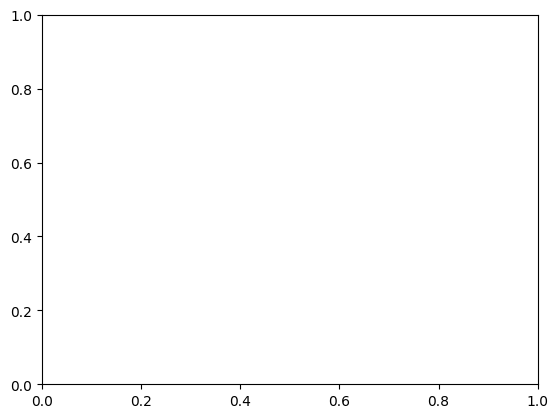

In [14]:
# Plotting the muon eta

histoplot(truth_muon_pt)

Now we create a mask to select only events with atleast 2 muons (as we have $Z \rightarrow \mu^{+}\mu^{-}$)

In [ ]:
#create a mask that will only consider events with atleast 2 muons
mask = ak.num(truth_muon_pt) >= 2

#Muon Mass
mu_mass = 0.105 #in units of GeV

#Apply the mask to select those events with atleast 2 muons
valid_truth_muon_pt = truth_muon_pt[mask]
valid_truth_muon_eta = truth_muon_eta[mask]
valid_truth_muon_phi = truth_muon_phi[mask]


In [ ]:
#The two muons selected are leading and subleading muons
first_muon_pt = valid_truth_muon_pt[:, 0]
second_muon_pt = valid_truth_muon_pt[:, 1]
first_muon_eta = valid_truth_muon_eta[:, 0]
second_muon_eta = valid_truth_muon_eta[:, 1]
first_muon_phi = valid_truth_muon_phi[:, 0]
second_muon_phi = valid_truth_muon_phi[:, 1]


In [ ]:
#Creating 4-vectors with pt,eta,phi and mass of muons
first_mu_4vec = vector.arr({"pt" : first_muon_pt, "eta" : first_muon_eta, "phi" : first_muon_phi, "mass" : np.full_like(first_muon_pt, mu_mass)})
second_mu_4vec = vector.arr({"pt" : second_muon_pt, "eta" : second_muon_eta, "phi" : second_muon_phi, "mass" : np.full_like(second_muon_pt, mu_mass)})


# Exercise: Plot the $p_T$ distribution of leading and subleading muon with x-range 0 to 200 

Reconstructing mass from the addition of 2 vectors

In [ ]:
dimuon_4vec = first_mu_4vec + second_mu_4vec

dimuon_mass = dimuon_4vec.mass

# Exercise: Plot the di-muon mass distribution, $M_{\mu\mu}$ with title: 'di-muon mass', nbins=70, xmin=50 and xmax=150

In [ ]:
hisoplot(dimuon_mass, 'di-muon mass', 71, 50, 150)

In [ ]:
#Select the bins of the histogram
bins = np.linspace(50,120,71)
#Plot the histogram of dimuon mass
plt.hist(dimuon_mass, bins = bins, histtype= 'step', label= 'Truth Di-Muon mass', density = True, color='red')

# Set x-axis range
plt.xlim(50, 150)

We now see that these are the first 10 values listed as in the `muon_pt` array, but without the sub-arrays.

## B. Electron Resolution

We would like to do the same thing as we did for muons, but now for electrons. To do this, we first select the first sample from our electron dataset.

In [ ]:
# We will use the first entry in 'list', from the 'e_e' dataset
value = samples['e_e']['list'][0]
print(f"{value = }")

# We can keep this file URL to peek into it and understanding what our data looks like
e_e_file = value

In [ ]:
# Accessing the file from the online database (":analysis" opens the tree in a desired manner)
if local_files:

    # Download the file, use a local copy
    local_filename = e_e_file.split("/")[-1]
    print(f"Downloading {e_e_file} to {local_filename} ...")
    e_e_file_renamed = e_e_file.replace("simplecache::", "") #Added by SS to remove simpleCache from name
    with requests.get(e_e_file_renamed, stream=True) as r:
        r.raise_for_status()
        with open(local_filename, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

    tree = uproot.open(local_filename + ":analysis")
else: # Stream files
    tree = uproot.open(e_e_file + ":analysis")

# The number of entries in the tree can be viewed
print("\n The number of entries in the tree are:", tree.num_entries)

# The number of variables in the tree can be viewed
print("\n The number of variables in the tree is:", len(tree.keys()))

We now need to take the following variables from our `tree` and create arrays for them:

* `truth_elec_pt`: transverse momentum of the truth electrons

* `truth_elec_eta`: pseudo-rapidity of the truth electrons

* `truth_elec_phi`: azimuthal angle of the truth electrons

In [ ]:
# Define what variables are important to our analysis
elec_variables = ['truth_elec_pt', 'truth_elec_eta', 'truth_elec_phi']

# To see all the data for our given variables
tree.iterate(elec_variables, library="ak");

In [ ]:
for array in tree.iterate(elec_variables, library="ak"):
    # Creating arrays for truth_elec_pt, truth_elec_eta, and truth_elec_phi variables
    truth_elec_pt = array["truth_elec_pt"]
    truth_elec_eta = array["truth_elec_eta"]
    truth_elec_phi = array["truth_elec_phi"]

# Now try to recreate the di-electron Mass

# Exercise 1 : Try to get the standard deviation of di-muon and di-electron mass distribution and compare them?

# Exercise 2: If they appear to have significantly different values, guess the reason why?

*Hint: Try to think in terms of reconstruction of electrons vs muons